# Set up : normal ,  preprocessed

### **All Libraries**

In [ ]:
# Data Handling
import pandas as pd

# Text Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Model Training & Splitting
from sklearn.model_selection import train_test_split

# Models
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import SVC, NuSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Timing Execution
import time


### **Preparation du fichier / Analyse**

In [ ]:
import pandas as pd

# Load the CSV file
df = pd.read_csv("IMDB_RAW.csv")

# Rename the first two columns
df.rename(columns={df.columns[0]: "Text", df.columns[1]: "Label"}, inplace=True)

# Replace values in the Label column
df["Label"] = df["Label"].replace({"positive": "POS", "negative": "NEG"})

# Count duplicates before removing them
duplicates_count = df.duplicated(subset=["Text"]).sum()

# Remove duplicate rows based on the "Text" column
df.drop_duplicates(subset=["Text"], keep="first", inplace=True)

# Save the modified CSV file
#df.to_csv("IMDB_PN.csv", index=False)

print(f"Processing complete: Columns renamed, labels updated, and {duplicates_count} duplicate(s) removed.")

Processing complete: Columns renamed, labels updated, and 418 duplicate(s) removed.


Sentiment Distribution:
 Label
POS    24884
NEG    24698
Name: count, dtype: int64


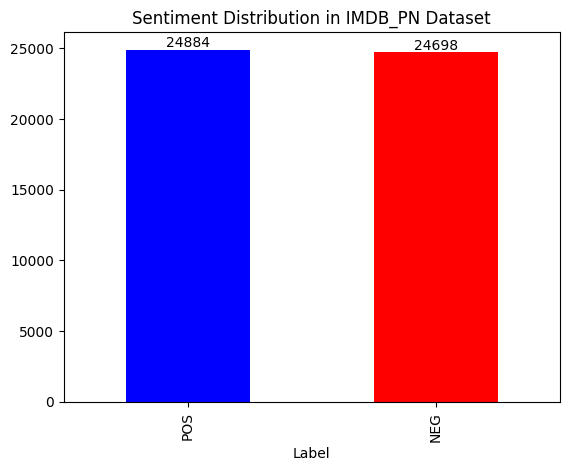

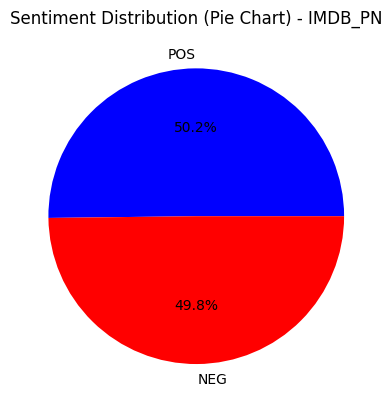

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
#df = pd.read_csv("IMDB_PN.csv")

# Count sentiment occurrences
sentiment_counts = df["Label"].value_counts()
print("Sentiment Distribution:\n", sentiment_counts)

# Define colors for the 2 ratings
colors = ["blue", "red"]

# Bar Chart
ax = sentiment_counts.plot(kind="bar", color=colors)
plt.title("Sentiment Distribution in IMDB_PN Dataset")

# Add the exact number on top of each bar
for i, v in enumerate(sentiment_counts):
    ax.text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=10)  # Adjust vertical position if needed

#plt.savefig("bar_chart_pn.png")
plt.show()

# Pie Chart
sentiment_counts.plot(kind="pie", autopct="%1.1f%%", colors=colors)
plt.title("Sentiment Distribution (Pie Chart) - IMDB_PN")
plt.ylabel("")
#plt.savefig("pie_chart_pn.png")
print("\n")
plt.show()


In [ ]:
#df = pd.read_csv("IMDB_PN.csv")

# Convert POS → 1 and NEG → 0
df["Label"] = df["Label"].replace({"POS": 1, "NEG": 0})

df.to_csv("IMDB.csv", index=False)

<ipython-input-6-b063b260e1dc>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Label"] = df["Label"].replace({"POS": 1, "NEG": 0})


### **Prétraitement**

In [ ]:
import pandas as pd
import string
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem.isri import ISRIStemmer
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
def remove_br_tags(text):
    if isinstance(text, str):
        return text.replace('<br />', ' ')
    return ''

def convert_to_lowercase(text):
    if isinstance(text, str):
        return text.lower()
    return ''

def remove_non_latin(text):
    if isinstance(text, str):
        return re.sub(r'[^a-z\s]', ' ', text)  # Replace non-latin characters with a space
    return ''

def tokenization(text):
    if isinstance(text, str):
        return re.findall(r'\S+', text)  # Matches sequences of non-space characters
    return []

def remove_ENG_stopwords(tokens):
    if isinstance(tokens, list):
        return [word for word in tokens if word not in ENGLISH_STOP_WORDS]
    return []

def get_root(word, stemmer):
    if isinstance(word, str):
        return stemmer.stem(word)
    return word

def stemming_ENG(tokens):
    stemmer = PorterStemmer()
    return [get_root(token, stemmer) for token in tokens]

def rejoin_tokens(tokens):
    filtered_tokens = [token for token in tokens if isinstance(token, str) and token.strip()]
    return ' '.join(filtered_tokens)

In [ ]:
def IMDB_pretraitement(text):
    if isinstance(text, str):
        # Step 1: Remove <br /> tags
        text = remove_br_tags(text)

        # Step 4: Convert to lowercase
        text = convert_to_lowercase(text)

        # Step 5: Remove non-latin characters
        text = remove_non_latin(text)

        # Step 6: Tokenization (split text into tokens)
        tokens = tokenization(text)

        # Step 7: Remove English stopwords
        tokens = remove_ENG_stopwords(tokens)

        # Step 8: Apply stemming (Porter Stemmer for English)
        tokens = stemming_ENG(tokens)

        # Step 9: Rejoin tokens into a single string
        return rejoin_tokens(tokens)

    return ''

In [ ]:
print(f"Start processing IMDB ...\n")
IMDB = pd.read_csv("/content/IMDB.csv")
IMDB["Text"] = [IMDB_pretraitement(text) for text in df["Text"]]
IMDB.to_csv("/content/IMDB_Pre.csv", index=False)
print(f"Finished processing IMDB!\n")

Start processing IMDB ...

Finished processing IMDB!



# Set up : Algorithms Functions

### Libraries

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import time

### **Visualisation / Metrics**

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_and_visualize_results(results):
    cm = results["Confusion Matrix"]
    title = f"{results['Dataset']} with {results['Algorithm']}"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 3.5), gridspec_kw={'width_ratios': [1, 1.1]})
    fig.suptitle(title, fontsize=16, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
                square=True, linewidths=0, linecolor='white', annot_kws={"size": 13})
    ax1.set_xlabel('Predicted Label', fontsize=13)
    ax1.set_ylabel('True Label', fontsize=13)
    ax1.set_title('Confusion Matrix', fontsize=14)
    ax1.set_xticklabels(['Negative', 'Positive'], fontsize=12)
    ax1.set_yticklabels(['Negative', 'Positive'], fontsize=12)

    ax2.axis('off')
    ax2.set_title('Overall Performance', fontsize=14, fontweight='bold', loc='left')

    metrics_list = [
        ("Accuracy", results['Accuracy']),
        ("Macro F1", results['Macro F1']),
        ("Weighted F1", results['Weighted F1']),
        ("Execution Time (s)", results['Execution Time (s)']),
        ("# Positive Samples", results['Number of Positive Samples']),
        ("# Negative Samples", results['Number of Negative Samples'])
    ]

    y_text = 0.95
    for name, value in metrics_list:
        ax2.text(0.01, y_text, f"{name}: {value}", fontsize=13, va='top')
        y_text -= 0.08

    plt.tight_layout()
    plt.subplots_adjust(top=0.82)
    plt.show()


### **Vectorize**

In [ ]:
import time
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix

def vectorize_text_data(csv_path, sample_percentage=1.0):
    df = pd.read_csv(csv_path, encoding='utf-8-sig')
    df = df[df['Text'].notna() & (df['Text'] != "")]

    if sample_percentage < 1.0:
        df = df.sample(frac=sample_percentage, random_state=42).reset_index(drop=True)

    X = df['Text']
    y = df['Label']

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Vectorization
    vectorizer = TfidfVectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    return X_train_tfidf, X_test_tfidf, y_train, y_test, df

### **Traitement**

In [ ]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    roc_auc_score, confusion_matrix
)

def run_model_on_vectorized_data(X_train_tfidf, X_test_tfidf, y_train, y_test, df,
                                 model_class, model_name, dataset_name, model_params=None):
    # === Training & Prediction
    model = model_class(**(model_params or {}))
    start_time = time.time()
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    execution_time = time.time() - start_time
    cm = confusion_matrix(y_test, y_pred)

    # === Metrics
    precision_per_class = precision_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)
    recall_per_class = recall_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)
    f1_per_class = f1_score(y_test, y_pred, average=None, labels=[0, 1], zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)
    try:
        auc = roc_auc_score(y_test, model.predict_proba(X_test_tfidf)[:, 1])
    except:
        auc = None

    results = {
        "Dataset": dataset_name,
        "Algorithm": model_name,
        "Confusion Matrix": cm,
        "Accuracy": round(accuracy, 4),
        "Macro F1": round(macro_f1, 4),
        "Weighted F1": round(weighted_f1, 4),
        "ROC AUC": round(auc, 4) if auc is not None else "N/A",
        "Execution Time (s)": round(execution_time, 4),
        "Number of Positive Samples": len(df[df['Label'] == 1]),
        "Number of Negative Samples": len(df[df['Label'] == 0]),
        "y_test": y_test,
        "y_pred": y_pred
    }

    # === Visualization directly inside
    title = f"{dataset_name} with {model_name}"
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [1, 1.1]})
    fig.suptitle(title, fontsize=14, fontweight='bold')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
                square=True, linewidths=0, linecolor='white')
    ax1.set_xlabel('Predicted Label')
    ax1.set_ylabel('True Label')
    ax1.set_title('Confusion Matrix', fontsize=12)
    ax1.set_xticklabels(['Negative', 'Positive'])
    ax1.set_yticklabels(['Negative', 'Positive'])

    ax2.axis('off')
    ax2.set_title('Overall Performance', fontsize=12, fontweight='bold', loc='left')

    metrics_list = [
        ("Accuracy", results['Accuracy']),
        ("Macro F1", results['Macro F1']),
        ("Weighted F1", results['Weighted F1']),
        ("ROC AUC", results['ROC AUC']),
        ("Execution Time (s)", results['Execution Time (s)']),
        ("# Positive Samples", results['Number of Positive Samples']),
        ("# Negative Samples", results['Number of Negative Samples'])
    ]

    y_text = 0.95
    for name, value in metrics_list:
        ax2.text(0.01, y_text, f"{name}: {value}", fontsize=11, va='top')
        y_text -= 0.07

    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    plt.show()

    return results


### **Hyper Parameter Testing Function (one datasets)**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

def test_model_with_param_from_vectorized_data(
    X_train_tfidf, X_test_tfidf, y_train, y_test, df,
    model_class, param_name, param_values, dataset_label="Dataset",
    base_color="steelblue", lighter_color=None
):
    print("\n\n=== Default Run ===\n")
    default_result = run_model_on_vectorized_data(
        X_train_tfidf, X_test_tfidf, y_train, y_test, df,
        model_class=model_class,
        model_name=f"{model_class.__name__} (default)",
        dataset_name=dataset_label
    )
    default_macro_f1 = default_result["Macro F1"]

    print("\n\n=== Parameter Tuning ===\n")
    macro_f1_scores = []
    valid_values = []

    for val in param_values:
        try:
            model = model_class(**{param_name: val})
            model.fit(X_train_tfidf, y_train)
            y_pred = model.predict(X_test_tfidf)
            macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
            valid_values.append(val)
            macro_f1_scores.append(macro_f1)
            print(f"{param_name} = {val} → Macro F1 = {round(macro_f1, 4)}")
        except Exception as e:
            print(f"Skipped {param_name} = {val} due to error: {e}")

    print("\n\n=== Plot: Macro F1 vs Parameter ===\n")
    plt.figure(figsize=(7, 4))
    plt.plot(valid_values, macro_f1_scores, marker='o', linestyle='--', color=base_color)
    plt.title(f"{model_class.__name__} on {dataset_label}\nMacro F1 vs {param_name}", fontsize=13)
    plt.xlabel(param_name)
    plt.ylabel("Macro F1")
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    best_index = macro_f1_scores.index(max(macro_f1_scores))
    best_param_value = valid_values[best_index]

    print("\n\n=== Final Run with Best Parameter ===\n")
    best_result = run_model_on_vectorized_data(
        X_train_tfidf, X_test_tfidf, y_train, y_test, df,
        model_class=model_class,
        model_name=f"{model_class.__name__} (best {param_name}={best_param_value})",
        dataset_name=dataset_label,
        model_params={param_name: best_param_value}
    )
    best_macro_f1 = best_result["Macro F1"]

    print("\n\n=== Comparison Plot (Horizontal) ===\n")
    labels = ['Default', 'Tuned']
    macro_f1_vals = [default_macro_f1, best_macro_f1]
    y = range(len(labels))
    width = 0.4

    # Use lightened and normal colors
    lighter = lighter_color if lighter_color else "lightgray"
    darker = base_color

    plt.figure(figsize=(6, 2.8))
    bars = plt.barh(y, macro_f1_vals, height=width, color=[lighter, darker])
    for i, bar in enumerate(bars):
        width_val = bar.get_width()
        plt.text(width_val + 0.01, bar.get_y() + bar.get_height()/2., f'{width_val:.4f}', va='center', fontsize=9)

    plt.yticks(ticks=y, labels=labels)
    plt.xlim(0, 1)
    plt.xlabel("Macro F1 Score")
    plt.title(f"{model_class.__name__} - Macro F1 Before vs After Tuning")
    plt.tight_layout()
    plt.show()

    return {
        "Dataset": dataset_label,
        "Model": model_class.__name__,
        "Param Name": param_name,
        "Default Value": "default",
        "Best Value": best_param_value,
        "Macro F1 (Default)": round(default_macro_f1, 4),
        "Macro F1 (Tuned)": round(best_macro_f1, 4),
        "Color": base_color
    }


### **All tuning results**

In [35]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects


def plot_all_models_comparison(summary_df):
    models = summary_df["Model"]
    default_scores = summary_df["Macro F1 (Default)"]
    tuned_scores = summary_df["Macro F1 (Tuned)"]
    best_params = summary_df["Best Value"]
    param_names = summary_df["Param Name"]
    colors = summary_df["Color"]  # base color per model

    # Manual dictionary mapping for default values
    default_values = {
        "MultinomialNB": "1.0",
        "LinearSVC": "1.0",
        "LogisticRegression": "1.0",
        "RandomForestClassifier": "100",
        "KNeighborsClassifier": "5",
        "AdaBoostClassifier": "50"
    }

    # Get the number of models
    num_models = len(models)
    y_pos = range(num_models)
    height = 0.20  # thinner bars

    fig = plt.figure(figsize=(14, 6))  # wider figure to accommodate outside text
    ax = fig.add_subplot(111)

    # Loop in reverse order: start from the last element and go backward
    for idx, i in enumerate(reversed(range(num_models))):
        # Use the reversed index for positioning
        plot_pos = idx

        base = colors[i]
        lighter = {
            "darkorange": "moccasin",
            "teal": "paleturquoise",
            "crimson": "lightcoral",
            "forestgreen": "lightgreen",
            "purple": "thistle",
            "goldenrod": "khaki"
        }.get(base, "lightgray")

        # Plot bars with the new position
        ax.barh(plot_pos - height/2, default_scores[i], height=height, color=lighter)
        ax.barh(plot_pos + height/2, tuned_scores[i], height=height, color=base)

        # Annotate bar values (F1 scores) with white border and 2 decimal places
        txt = ax.text(default_scores[i] + 0.01, plot_pos - height/2, f"{default_scores[i]:.2f}",
                      va='center', fontsize=10, color='black')
        txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white'), path_effects.Normal()])

        txt = ax.text(tuned_scores[i] + 0.01, plot_pos + height/2, f"{tuned_scores[i]:.2f}",
                      va='center', fontsize=10, color='black')
        txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white'), path_effects.Normal()])



    # Set up the main plot with reversed models list
    ax.set_yticks(ticks=range(num_models))
    ax.set_yticklabels(models[::-1], fontsize=11)  # Reverse the labels
    ax.set_xlim(0, 1.0)  # Set x limit only to the plot area
    ax.set_xlabel("Macro F1 Score", fontsize=12)
    ax.set_title("Model Performance: Default vs Tuned", fontsize=14, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.6)

    # Make space on the right for annotations
    plt.subplots_adjust(right=0.75)

    # Add parameter labels outside the plot but aligned with bars
    for idx, i in enumerate(reversed(range(num_models))):
        plot_pos = idx
        model_name = models[i]
        default_value = default_values.get(model_name, "N/A")  # Get default value from dictionary

        param_label_default = f"{param_names[i]} = {default_value}"
        param_label_tuned = f"{param_names[i]} = {best_params[i]}"

        # Add text directly using axes coordinates to ensure alignment
        ax.text(1.05, plot_pos - height/2, param_label_default, va='center', fontsize=10, transform=ax.transData)
        ax.text(1.05, plot_pos + height/2, param_label_tuned, va='center', fontsize=10, transform=ax.transData)

    plt.show()

### **Victorize all data**

In [ ]:
# === Global table to store results from all algorithms
all_Algo_results = pd.DataFrame()

# === Step 0: Load and vectorize datasets
X_train1, X_test1, y_train1, y_test1, df1 = vectorize_text_data("IMDB.csv")
X_train2, X_test2, y_train2, y_test2, df2 = vectorize_text_data("IMDB_Pre.csv")

datasets = {
    "IMDB":                         (X_train1, X_test1, y_train1, y_test1, df1),
    "IMDB_Preprocessed":           (X_train2, X_test2, y_train2, y_test2, df2)
}


# IMDB - hyper parameter effect test / find the best for each algorithmes

In [ ]:
all_summary_results = pd.DataFrame()

## **Multinomial Naive Bayes**



=== Default Run ===



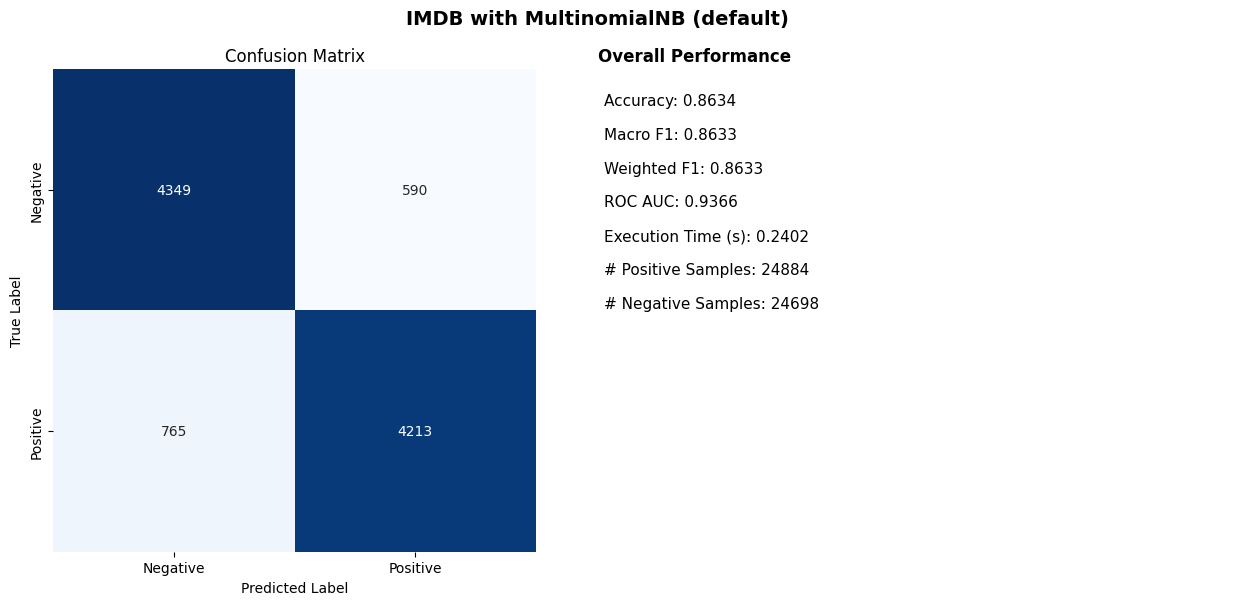



=== Parameter Tuning ===

alpha = 0.0001 → Macro F1 = 0.8271
alpha = 0.001 → Macro F1 = 0.8413
alpha = 0.01 → Macro F1 = 0.8518
alpha = 0.05 → Macro F1 = 0.8598
alpha = 0.1 → Macro F1 = 0.8616
alpha = 0.5 → Macro F1 = 0.8656
alpha = 1.0 → Macro F1 = 0.8633
alpha = 2.0 → Macro F1 = 0.8618
alpha = 5.0 → Macro F1 = 0.8568
alpha = 10.0 → Macro F1 = 0.8486


=== Plot: Macro F1 vs Parameter ===



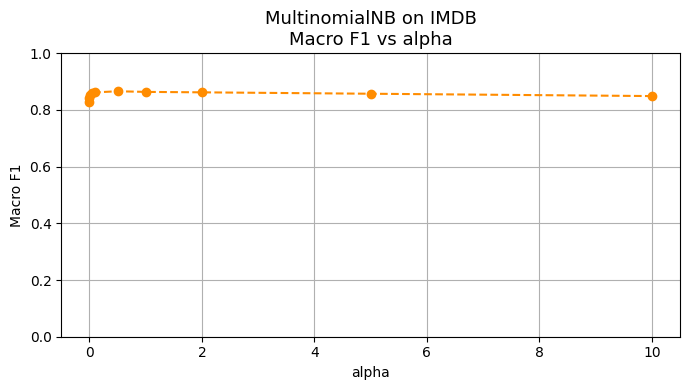



=== Final Run with Best Parameter ===



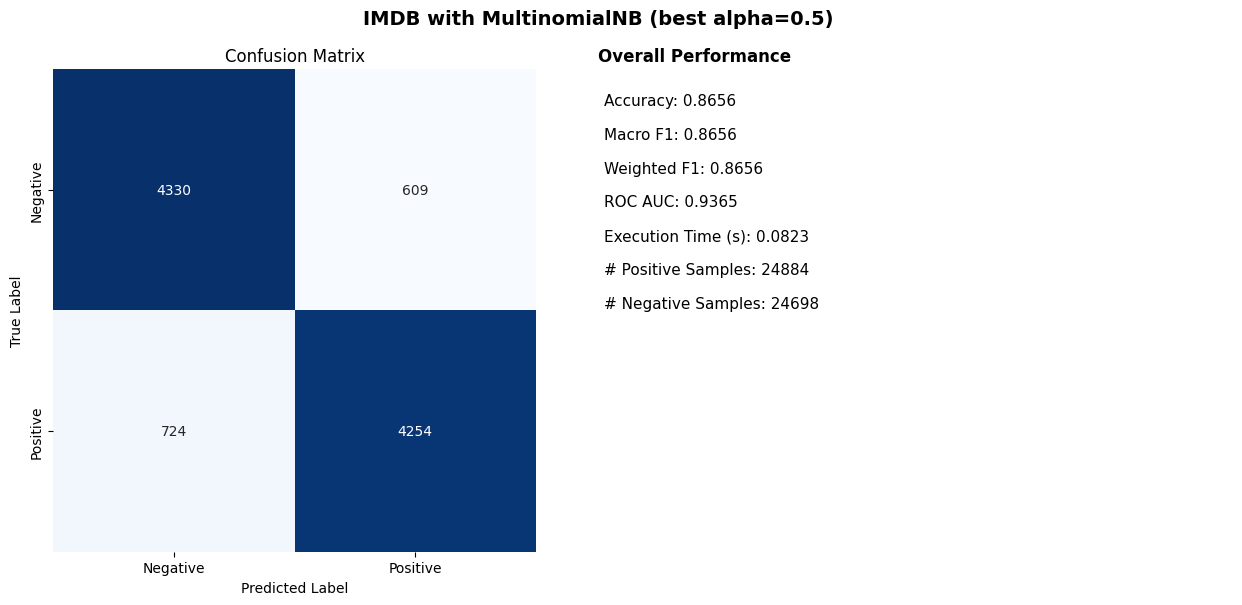



=== Comparison Plot (Horizontal) ===



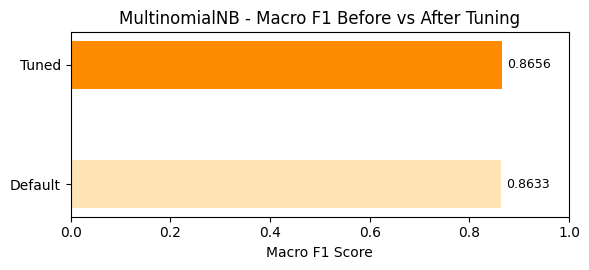

In [ ]:
from sklearn.naive_bayes import MultinomialNB

param_values = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
MNB_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=MultinomialNB,
    param_name="alpha",
    param_values=param_values,
    dataset_label="IMDB",
    base_color="darkorange",
    lighter_color="moccasin"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([MNB_summary_result])], ignore_index=True)


## **SVM (Linear)**



=== Default Run ===



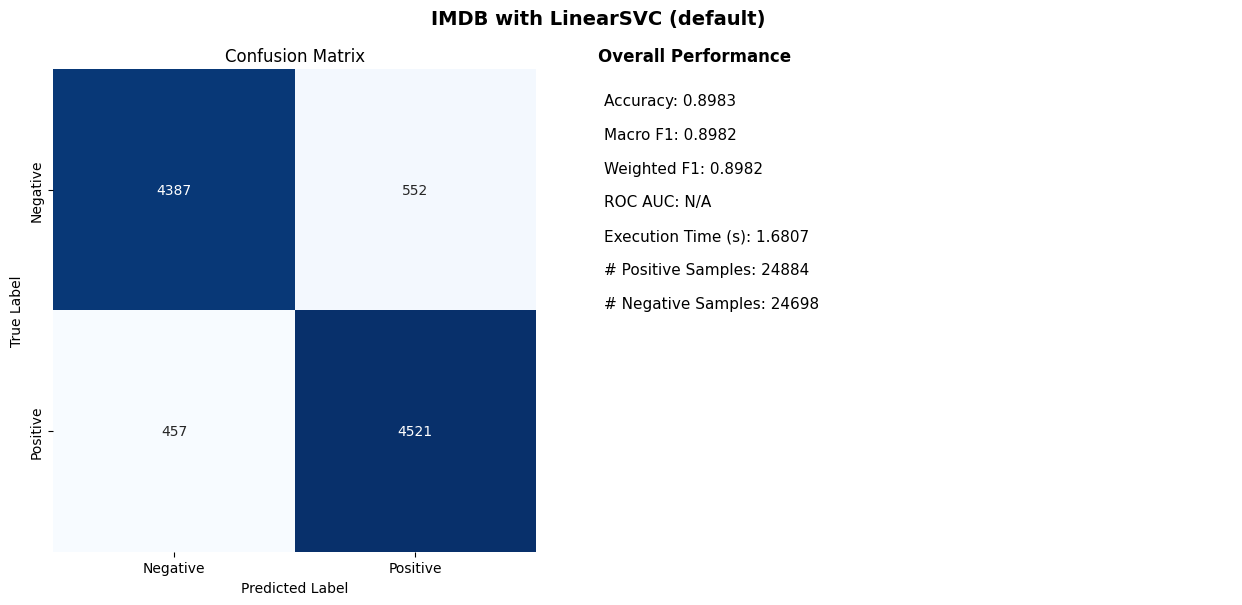



=== Parameter Tuning ===

C = 0.0001 → Macro F1 = 0.7601
C = 0.001 → Macro F1 = 0.7952
C = 0.01 → Macro F1 = 0.8613
C = 0.05 → Macro F1 = 0.8911
C = 0.1 → Macro F1 = 0.897
C = 1.0 → Macro F1 = 0.8982
C = 5.0 → Macro F1 = 0.8902
C = 10.0 → Macro F1 = 0.8831
C = 20.0 → Macro F1 = 0.8798
C = 50.0 → Macro F1 = 0.876


=== Plot: Macro F1 vs Parameter ===



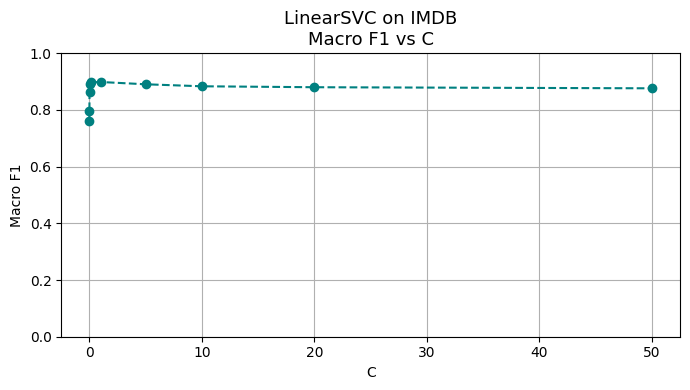



=== Final Run with Best Parameter ===



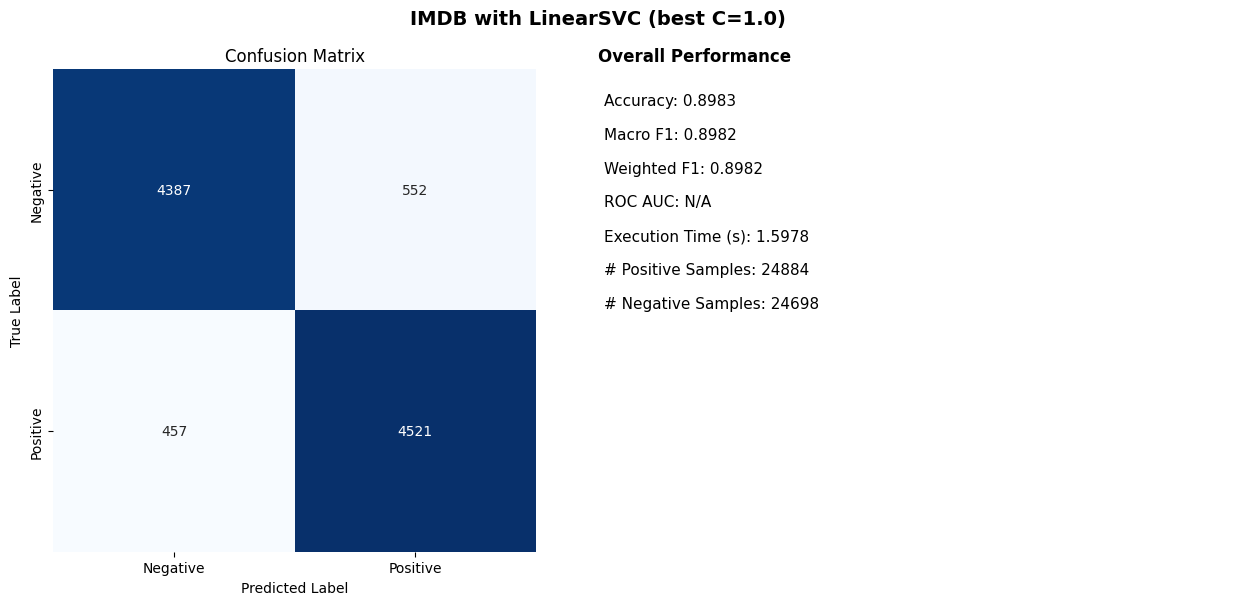



=== Comparison Plot (Horizontal) ===



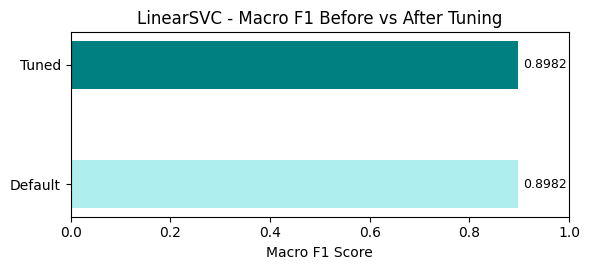

In [ ]:
from sklearn.svm import LinearSVC

param_values = [0.0001, 0.001, 0.01, 0.05, 0.1, 1.0, 5.0, 10.0, 20.0, 50.0]
SVM_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=LinearSVC,
    param_name="C",
    param_values=param_values,
    dataset_label="IMDB",
    base_color="teal",
    lighter_color="paleturquoise"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([SVM_summary_result])], ignore_index=True)


## **LogisticRegression**



=== Default Run ===



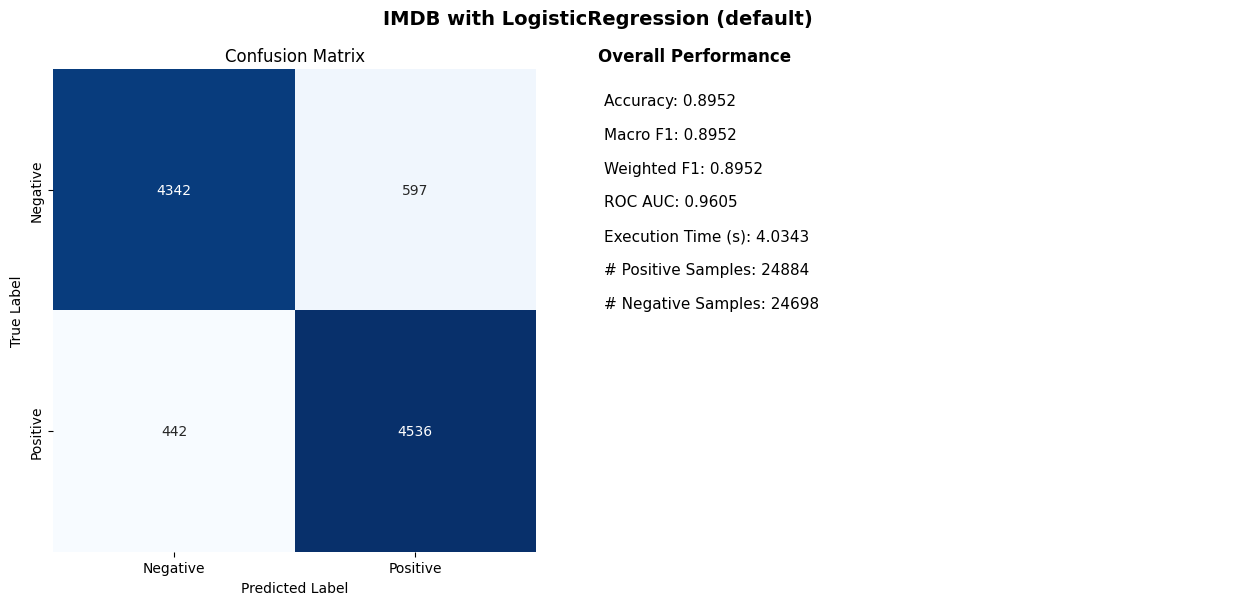



=== Parameter Tuning ===

C = 0.0001 → Macro F1 = 0.4409
C = 0.001 → Macro F1 = 0.7462
C = 0.01 → Macro F1 = 0.7985
C = 0.1 → Macro F1 = 0.8621
C = 0.5 → Macro F1 = 0.8896
C = 1.0 → Macro F1 = 0.8952
C = 5.0 → Macro F1 = 0.9006
C = 10.0 → Macro F1 = 0.898
C = 20.0 → Macro F1 = 0.8987
C = 50.0 → Macro F1 = 0.8944


=== Plot: Macro F1 vs Parameter ===



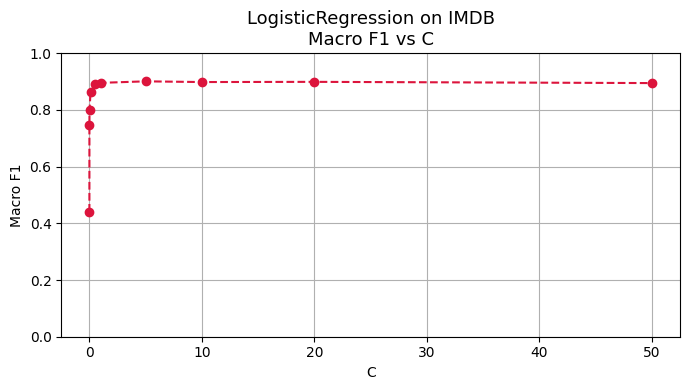



=== Final Run with Best Parameter ===



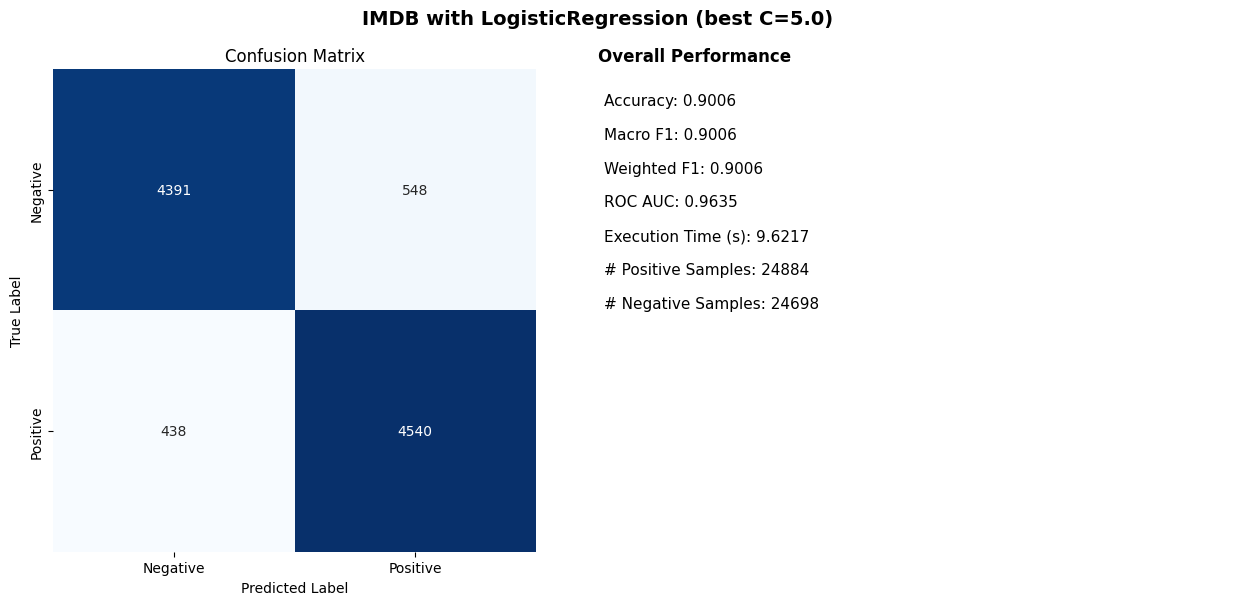



=== Comparison Plot (Horizontal) ===



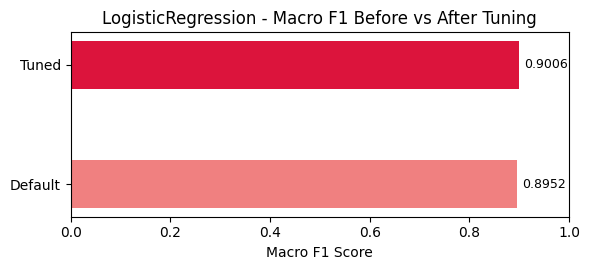

In [ ]:
from sklearn.linear_model import LogisticRegression

param_values = [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 20.0, 50.0]
LogReg_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=LogisticRegression,
    param_name="C",
    param_values=param_values,
    dataset_label="IMDB",
    base_color="crimson",
    lighter_color="lightcoral"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([LogReg_summary_result])], ignore_index=True)


## **RandomForest**



=== Default Run ===



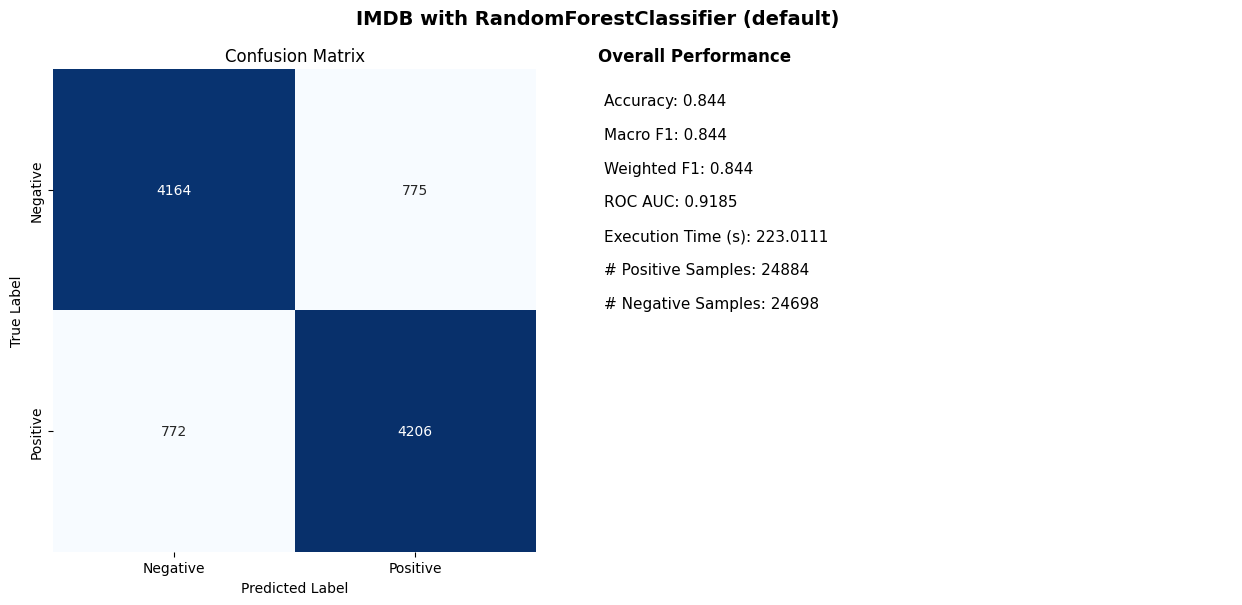



=== Parameter Tuning ===

n_estimators = 10 → Macro F1 = 0.7426
n_estimators = 20 → Macro F1 = 0.782
n_estimators = 50 → Macro F1 = 0.8171
n_estimators = 75 → Macro F1 = 0.8356
n_estimators = 100 → Macro F1 = 0.8349
n_estimators = 150 → Macro F1 = 0.8439
n_estimators = 200 → Macro F1 = 0.8476
n_estimators = 300 → Macro F1 = 0.8478
n_estimators = 400 → Macro F1 = 0.8505
n_estimators = 500 → Macro F1 = 0.8508


=== Plot: Macro F1 vs Parameter ===



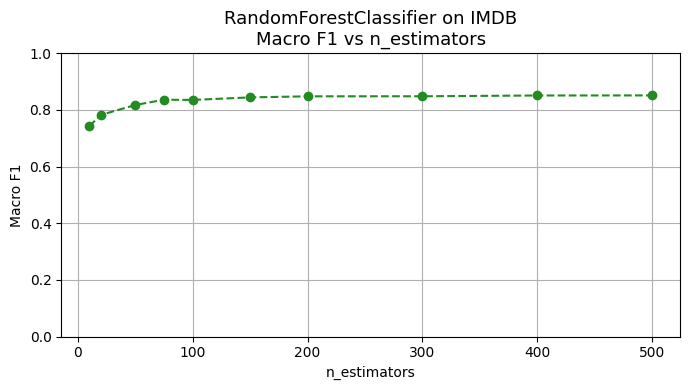



=== Final Run with Best Parameter ===



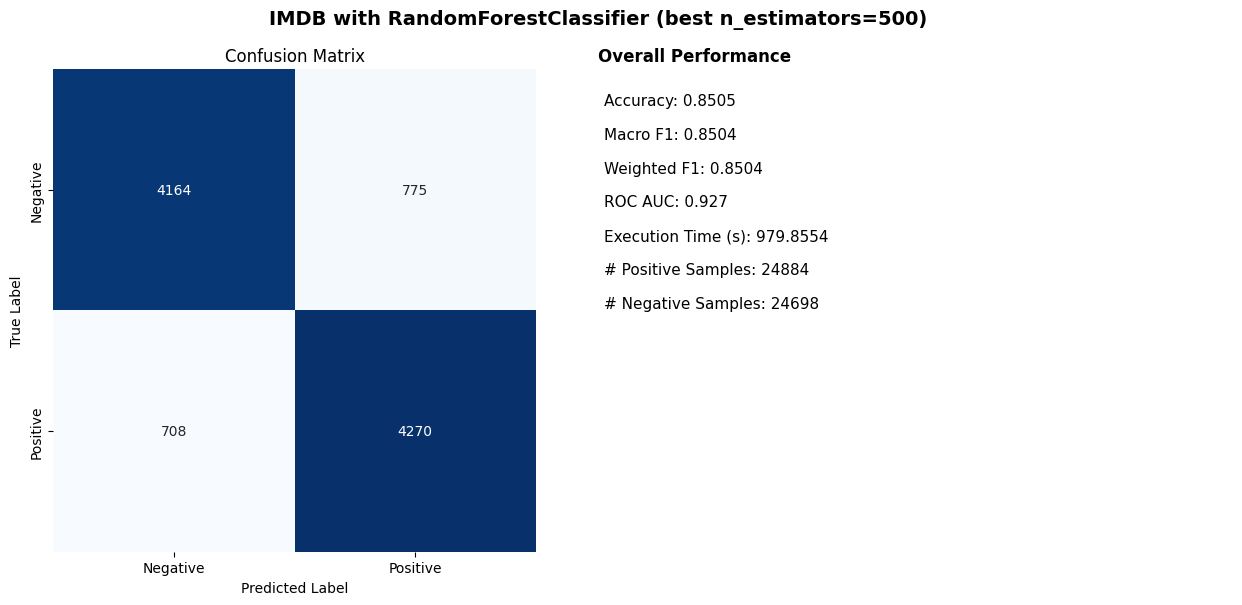



=== Comparison Plot (Horizontal) ===



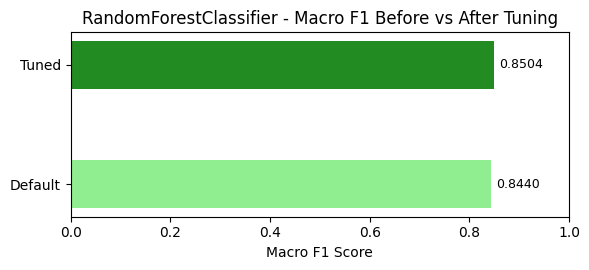

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_values = [10, 20, 50, 75, 100, 150, 200, 300, 400, 500]
RF_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=RandomForestClassifier,
    param_name="n_estimators",
    param_values=param_values,
    dataset_label="IMDB",
    base_color="forestgreen",
    lighter_color="lightgreen"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([RF_summary_result])], ignore_index=True)


## **KNeighborsClassifier**



=== Default Run ===



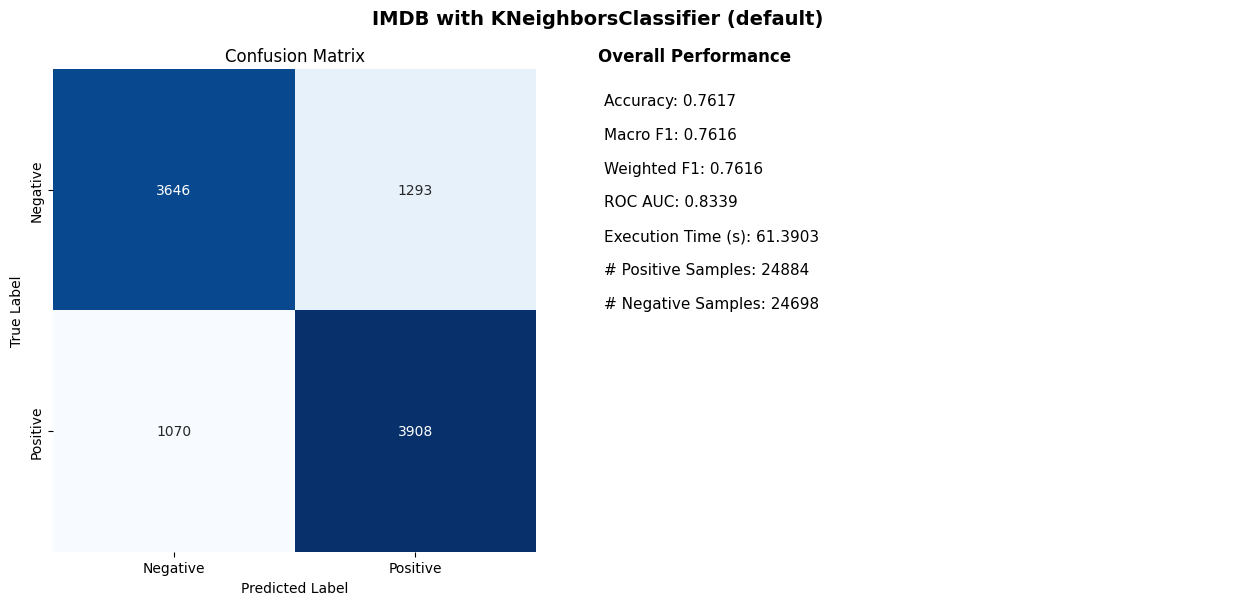



=== Parameter Tuning ===

n_neighbors = 1 → Macro F1 = 0.7355
n_neighbors = 3 → Macro F1 = 0.7569
n_neighbors = 5 → Macro F1 = 0.7616
n_neighbors = 7 → Macro F1 = 0.7672
n_neighbors = 9 → Macro F1 = 0.7741
n_neighbors = 11 → Macro F1 = 0.7754
n_neighbors = 15 → Macro F1 = 0.7745
n_neighbors = 20 → Macro F1 = 0.7683
n_neighbors = 30 → Macro F1 = 0.7634
n_neighbors = 50 → Macro F1 = 0.7581


=== Plot: Macro F1 vs Parameter ===



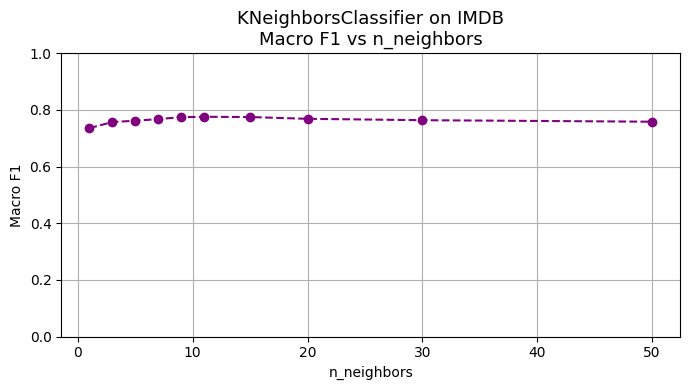



=== Final Run with Best Parameter ===



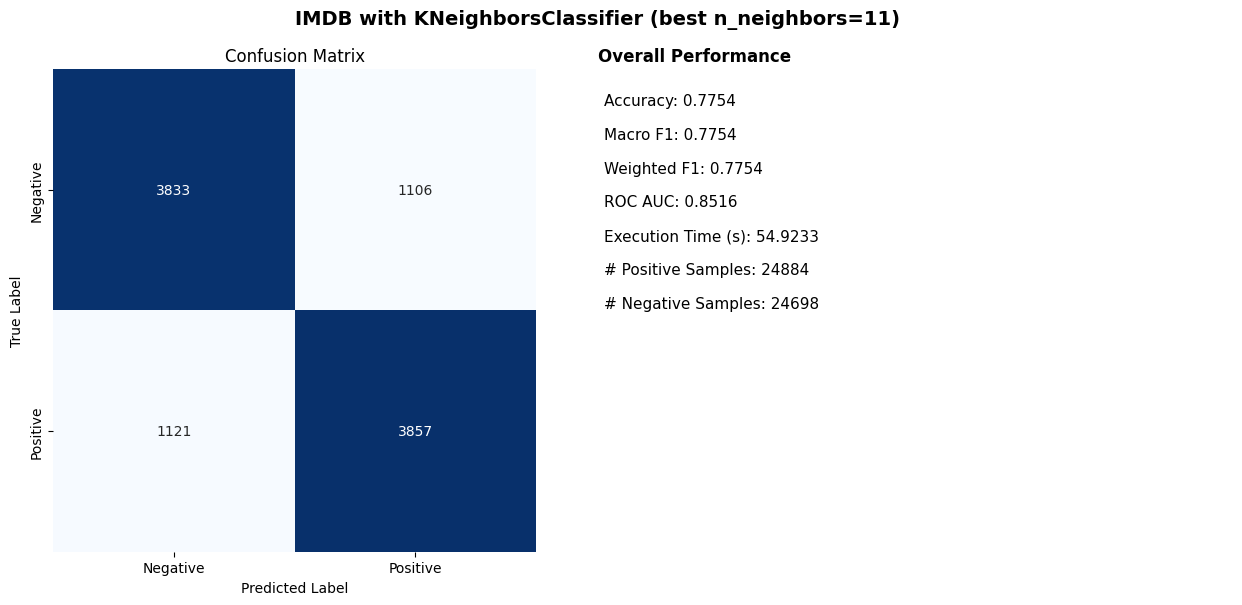



=== Comparison Plot (Horizontal) ===



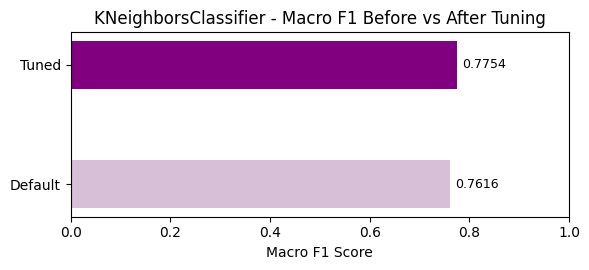

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

param_values = [1, 3, 5, 7, 9, 11, 15, 20, 30, 50]
KNN_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=KNeighborsClassifier,
    param_name="n_neighbors",
    param_values=param_values,
    dataset_label="IMDB",
    base_color="purple",
    lighter_color="thistle"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([KNN_summary_result])], ignore_index=True)


## **AdaBoostClassifier**



=== Default Run ===



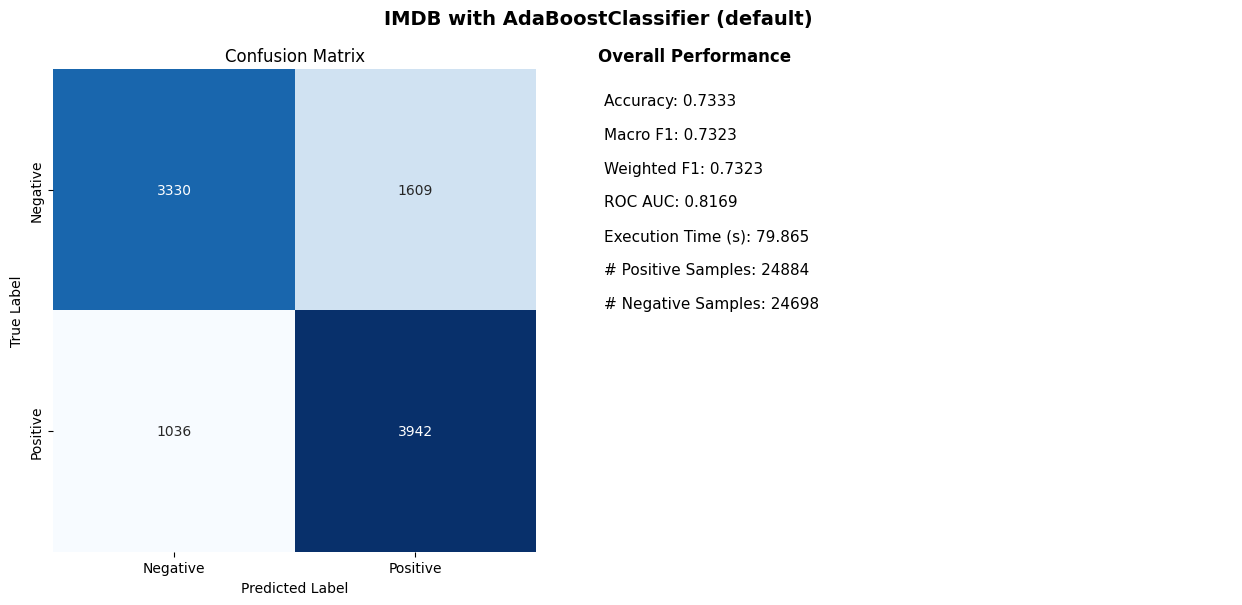



=== Parameter Tuning ===

n_estimators = 10 → Macro F1 = 0.5936
n_estimators = 20 → Macro F1 = 0.6882
n_estimators = 30 → Macro F1 = 0.7339
n_estimators = 50 → Macro F1 = 0.7323
n_estimators = 75 → Macro F1 = 0.7521
n_estimators = 100 → Macro F1 = 0.7646
n_estimators = 150 → Macro F1 = 0.7785
n_estimators = 200 → Macro F1 = 0.7918
n_estimators = 250 → Macro F1 = 0.8005
n_estimators = 300 → Macro F1 = 0.808


=== Plot: Macro F1 vs Parameter ===



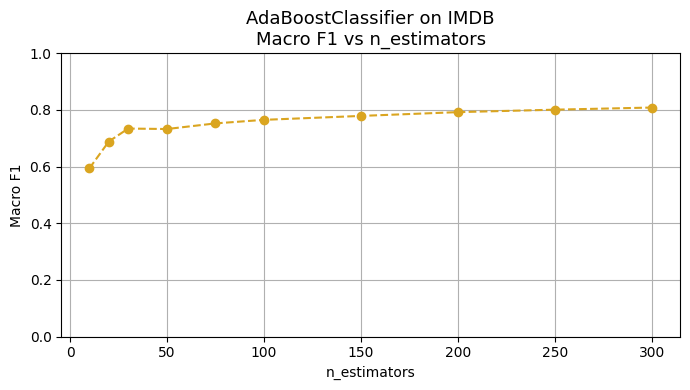



=== Final Run with Best Parameter ===



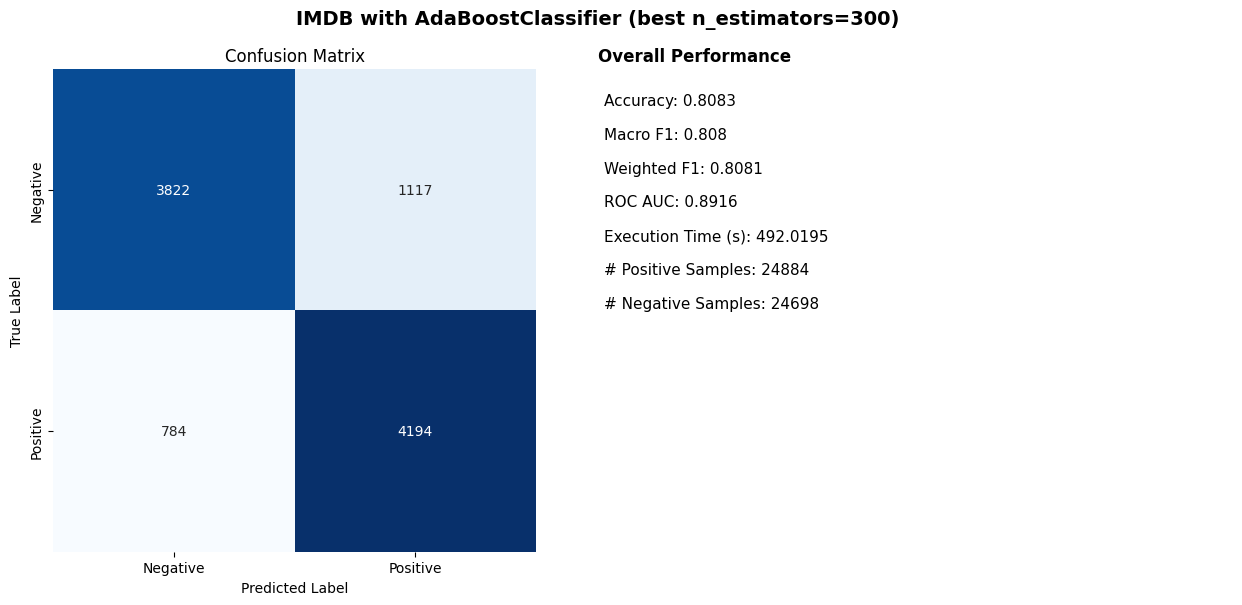



=== Comparison Plot (Horizontal) ===



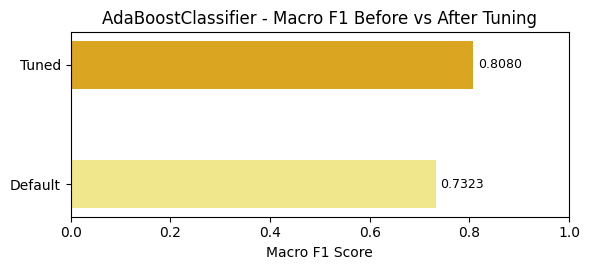

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

param_values = [10, 20, 30, 50, 75, 100, 150, 200, 250, 300]
AdaBoost_summary_result = test_model_with_param_from_vectorized_data(
    X_train_tfidf=X_train1,
    X_test_tfidf=X_test1,
    y_train=y_train1,
    y_test=y_test1,
    df=df1,
    model_class=AdaBoostClassifier,
    param_name="n_estimators",
    param_values=param_values,
    dataset_label="IMDB",
    base_color="goldenrod",
    lighter_color="khaki"
)

all_summary_results = pd.concat([all_summary_results, pd.DataFrame([AdaBoost_summary_result])], ignore_index=True)


## **All results**

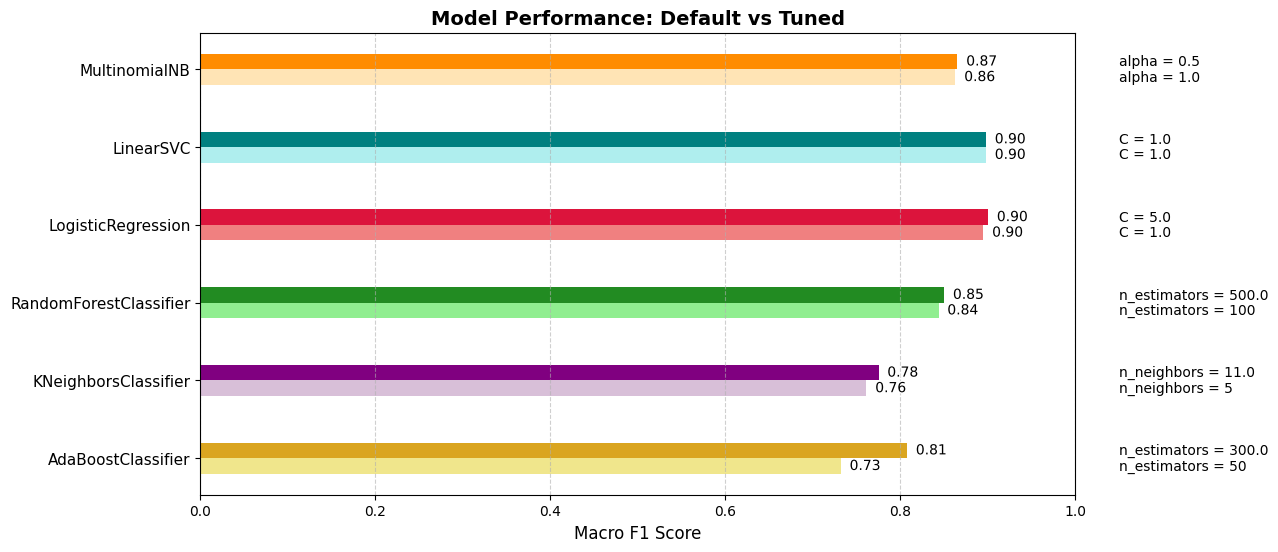

In [36]:
plot_all_models_comparison(all_summary_results)